In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
from google.colab import files
uploaded = files.upload()

Saving AB_Test_Data.xlsx to AB_Test_Data.xlsx


In [5]:
import pandas as pd

df = pd.read_excel("AB_Test_Data.xlsx")
df.head()

,User_ID,Group,Converted
0,1,A,0
1,2,A,1
2,3,A,0
3,4,A,1
4,5,A,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   User_ID    30 non-null     int64 
 1   Group      30 non-null     object
 2   Converted  30 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 852.0+ bytes


In [7]:
df.isnull().sum()

,0
User_ID,0
Group,0
Converted,0


In [8]:
df.describe()

,User_ID,Converted
count,30.000000,30.000000
mean,15.500000,0.633333
std,8.803408,0.490133
min,1.000000,0.000000
25%,8.250000,0.000000
50%,15.500000,1.000000
75%,22.750000,1.000000
max,30.000000,1.000000


In [9]:
conversion = df.groupby("Group")["Converted"].mean()
print(conversion)

Group
A    0.466667
B    0.800000
Name: Converted, dtype: float64


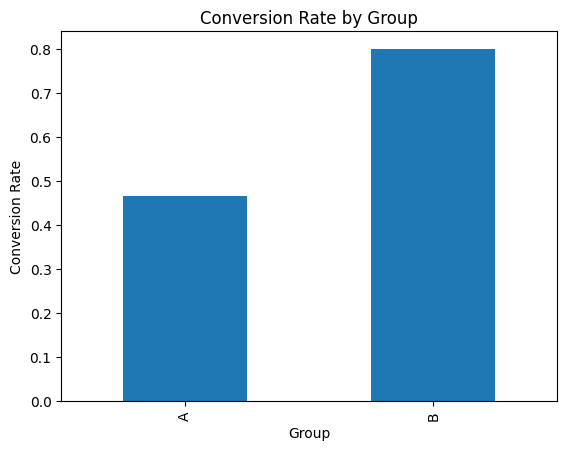

In [11]:
conversion.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

In [12]:
table = pd.crosstab(df["Group"], df["Converted"])

chi2, p, dof, expected = chi2_contingency(table)

print("P-value:", p)

P-value: 0.12965330542364764


In [13]:
if p < 0.05:
    print("Result: The difference is statistically significant.")
    print("The new website (Group B) performs better.")
else:
    print("Result: No significant difference between Group A and Group B.")

Result: No significant difference between Group A and Group B.
